# TAO ADCP Validation: TPOSE24 Simulated vs Observed Velocity

Compares TPOSE24 model velocity (`prof_Uestim`, `prof_Vestim`) against TAO ADCP observations (`prof_U`, `prof_V`) at the equatorial Pacific TAO mooring.

**Data:** `TAO_WO_2012_ADCP_v2_model.nc` from the MITprof framework  
**Location:** 0°N, 140°W (the only mooring with collocated obs+model in this file)  
**Period:** Oct–Dec 2012 (~hourly profiles, 91 days)  
**Depths:** 10–315 m (62 levels, 5 m spacing)

### Figures
1. Hovmöller: observed U and V (depth × time)
2. Hovmöller: simulated U and V (depth × time)
3. Hovmöller: velocity error (obs − model) for U and V
4. Time-mean depth profiles: obs vs model for U and V
5. RMS error and bias as a function of depth
6. Time series at selected depths (surface, thermocline, deep)
7. Scatter plots: obs vs model for U and V
8. Summary statistics table

In [28]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import cmocean.cm as cmo
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11})

DATA_PATH = '/data/SO3/edavenport/tpose24/oct2012_TP6Vel_3month/PROF_eq/TAO_WO_2012_ADCP_v2_model.nc'

## 1. Load and pre-process

In [ ]:
ds = xr.open_dataset(DATA_PATH)

lons  = ds['prof_lon'].values
lats  = ds['prof_lat'].values
depths = ds['prof_depth'].values            # (62,) metres
dates_raw = ds['prof_YYYYMMDD'].values      # YYYYMMDD float
times_raw = ds['prof_HHMMSS'].values        # HHMMSS float

U      = ds['prof_U'].values.astype(float)
V      = ds['prof_V'].values.astype(float)
Uestim = ds['prof_Uestim'].values.astype(float)
Vestim = ds['prof_Vestim'].values.astype(float)
Uw     = ds['prof_Uweight'].values.astype(float)

# Build datetime index from YYYYMMDD + HHMMSS
def parse_datetime(yyyymmdd, hhmmss):
    d = int(yyyymmdd)
    t = int(hhmmss)
    yr, mo, dy = d // 10000, (d % 10000) // 100, d % 100
    hh, mm, ss = t // 10000, (t % 10000) // 100, t % 100
    return pd.Timestamp(yr, mo, dy, hh, mm, ss)

timestamps = np.array([parse_datetime(d, t) for d, t in zip(dates_raw, times_raw)])

# --- Focus on the only mooring with collocated obs + model: 140°W ---
TARGET_LON = -10.
lon_mask   = lons == TARGET_LON
estim_mask = ~np.isnan(Uestim[lon_mask]).any(axis=1)   # profiles with model output

t_all  = timestamps[lon_mask][estim_mask]
U_all  = U[lon_mask][estim_mask]          # (n_prof, 62)
V_all  = V[lon_mask][estim_mask]
Ue_all = Uestim[lon_mask][estim_mask]
Ve_all = Vestim[lon_mask][estim_mask]

print(f'Mooring: {TARGET_LON}°E  ({abs(TARGET_LON):.0f}°W), 0°N')
print(f'Profiles: {len(t_all)}  |  Period: {t_all[0].date()} – {t_all[-1].date()}')
print(f'Depth levels: {len(depths)}  ({depths[0]:.0f}–{depths[-1]:.0f} m)')
print(f'Approx sampling: {len(t_all) / 91:.0f} profiles/day')

Mooring: -140.0°E  (140°W), 0°N
Profiles: 2183  |  Period: 2012-10-01 – 2012-12-30
Depth levels: 62  (10–315 m)
Approx sampling: 24 profiles/day


In [38]:
# Daily-average onto a regular time × depth grid
# (reduces noise and gives a clean Hovmöller)

day_index = pd.DatetimeIndex(t_all).normalize()   # floor to midnight
unique_days = pd.date_range(day_index.min(), day_index.max(), freq='D')
n_days, n_z = len(unique_days), len(depths)

def daily_average(arr2d, day_idx, unique_days):
    """Average arr2d (n_prof x n_z) into (n_days x n_z) with NaN masking."""
    out = np.full((len(unique_days), arr2d.shape[1]), np.nan)
    for i, day in enumerate(unique_days):
        sel = day_idx == day
        if sel.sum() == 0:
            continue
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            out[i] = np.nanmean(arr2d[sel], axis=0)
    return out

U_day  = daily_average(U_all,  day_index, unique_days)
V_day  = daily_average(V_all,  day_index, unique_days)
Ue_day = daily_average(Ue_all, day_index, unique_days) + U_day - U_day
Ve_day = daily_average(Ve_all, day_index, unique_days) + V_day - V_day

dU_day = U_day  - Ue_day   # obs - model
dV_day = V_day  - Ve_day

T = unique_days.to_pydatetime()   # x-axis
Z = -depths                        # negative = depth below surface

print(f'Daily grid: {n_days} days × {n_z} depths')

Daily grid: 91 days × 62 depths


## 2. Hovmöller: Observed velocity

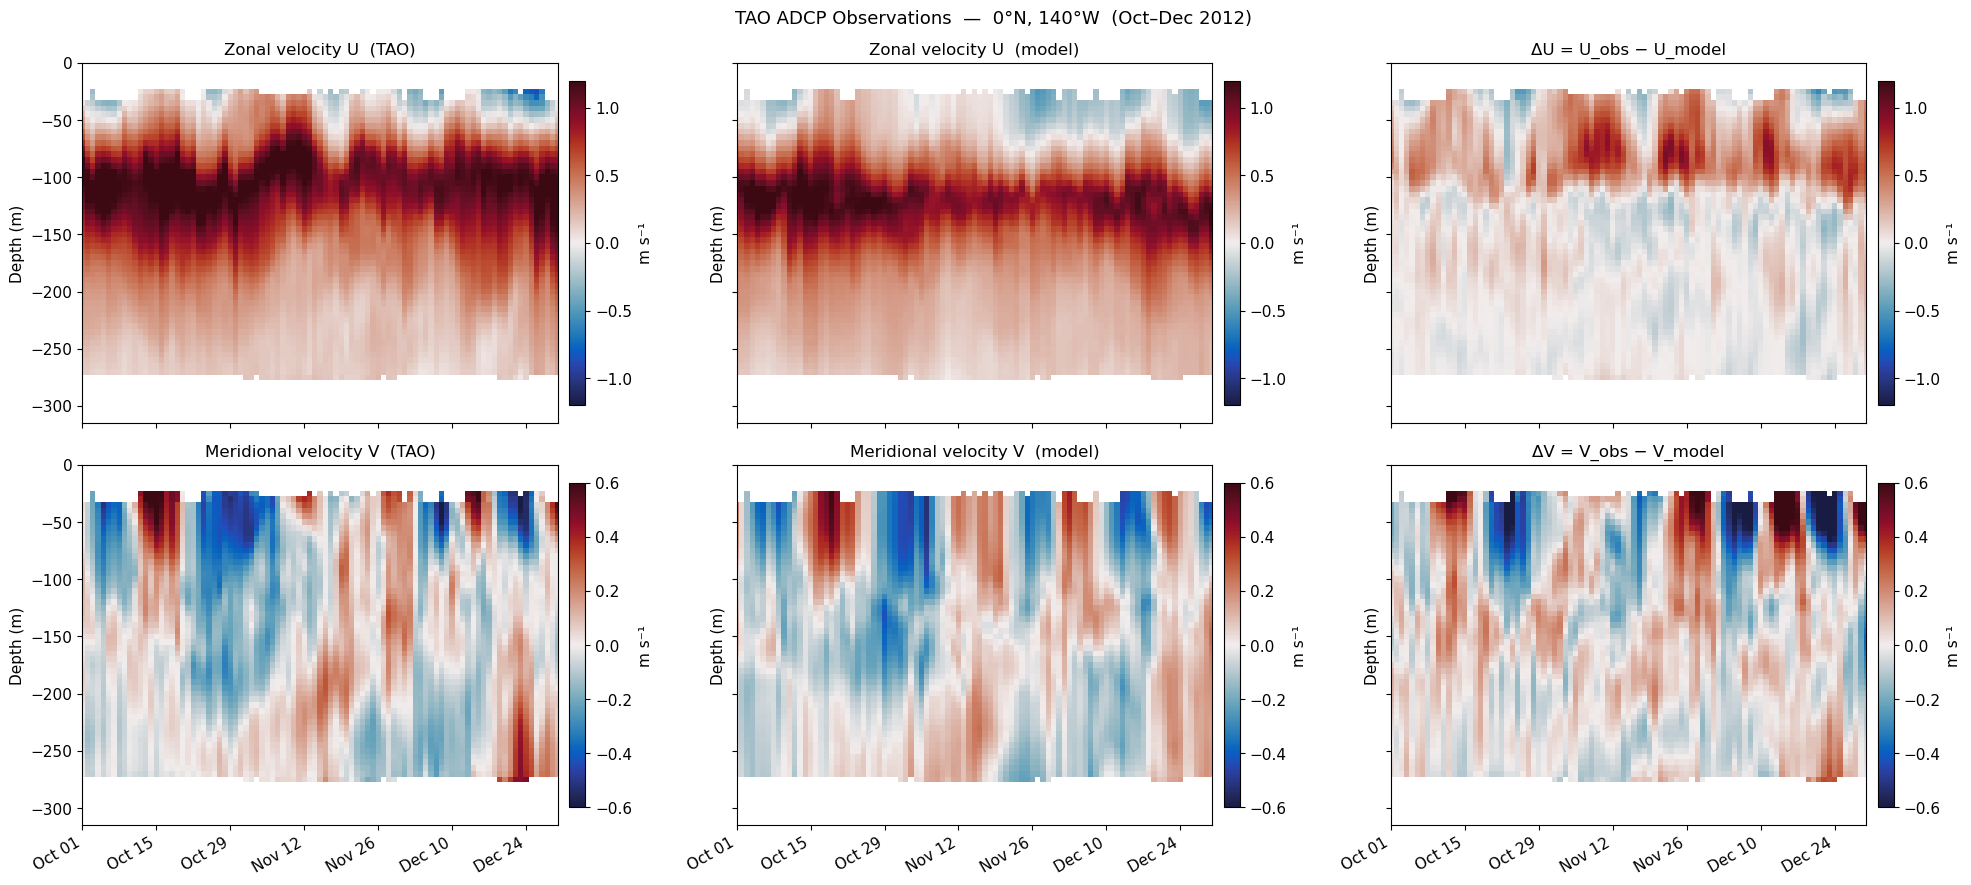

Saved fig1_140W_hovm.png


In [39]:
def hovm(ax, data, T, Z, cmap, vmax, label, title):
    """Hovmöller (time x depth) pcolor helper."""
    im = ax.pcolormesh(T, Z, data.T, cmap=cmap,
                       vmin=-vmax, vmax=vmax, shading='auto')
    ax.set_ylabel('Depth (m)')
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    cb = plt.colorbar(im, ax=ax, pad=0.02, shrink=0.9)
    cb.set_label(label)
    return im

fig, axes = plt.subplots(2, 3, figsize=(20, 9), sharex=True, sharey=True)
fig.suptitle('TAO ADCP Observations  —  0°N, 140°W  (Oct–Dec 2012)', fontsize=13, y=0.98)

hovm(axes[0,0], U_day, T, Z, cmo.balance, 1.2, 'm s⁻¹', 'Zonal velocity U  (TAO)')
hovm(axes[1,0], V_day, T, Z, cmo.balance, 0.6, 'm s⁻¹', 'Meridional velocity V  (TAO)')
hovm(axes[0,1], Ue_day, T, Z, cmo.balance, 1.2, 'm s⁻¹', 'Zonal velocity U  (model)')
hovm(axes[1,1], Ve_day, T, Z, cmo.balance, 0.6, 'm s⁻¹', 'Meridional velocity V  (model)')
hovm(axes[0,2], dU_day, T, Z, cmo.balance, 1.2, 'm s⁻¹', 'ΔU = U_obs − U_model')
hovm(axes[1,2], dV_day, T, Z, cmo.balance, 0.6, 'm s⁻¹', 'ΔV = V_obs − V_model')

for ax in axes.flatten():
    ax.set_ylim([-315, 0])
    ax.set_xlim([T[0], T[-1]])
    
fig.tight_layout()
plt.savefig('TAO_comparison/fig1_140W_hovm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig1_140W_hovm.png')

## 5. Time-mean depth profiles

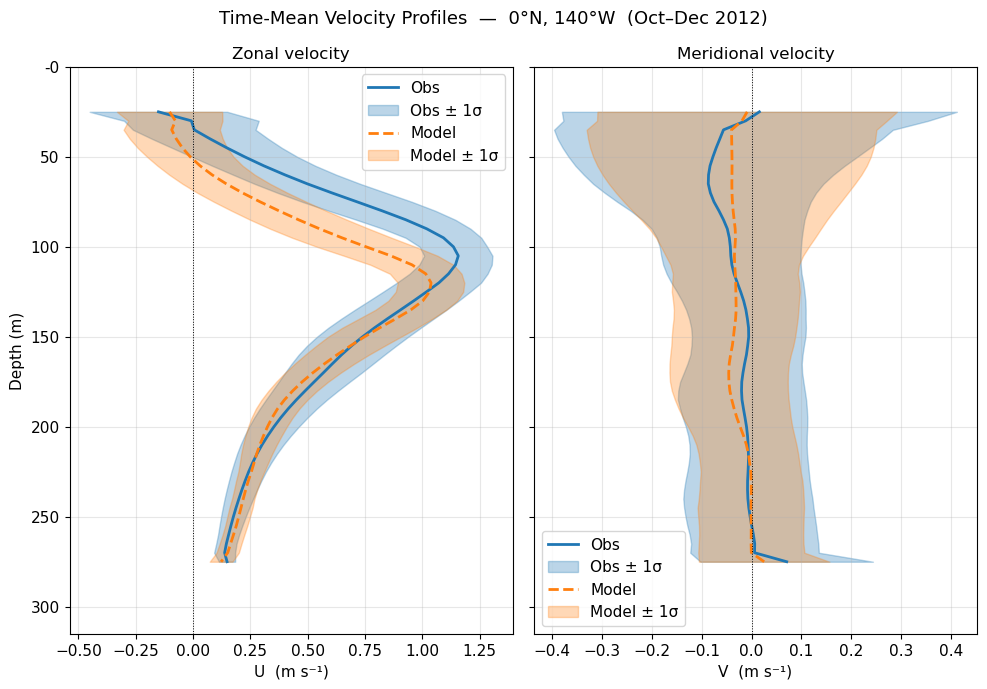

Saved fig4_mean_profiles.png


In [41]:
U_mean  = np.nanmean(U_day,  axis=0)
V_mean  = np.nanmean(V_day,  axis=0)
Ue_mean = np.nanmean(Ue_day, axis=0)
Ve_mean = np.nanmean(Ve_day, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 7), sharey=True)
fig.suptitle('Time-Mean Velocity Profiles  —  0°N, 140°W  (Oct–Dec 2012)', fontsize=13)

# U and its std dev
axes[0].plot(U_mean,  Z, color='C0', lw=2,   label='Obs')
axes[0].fill_betweenx(Z, U_mean - np.nanstd(U_day, axis=0), U_mean + np.nanstd(U_day, axis=0), color='C0', alpha=0.3, label='Obs ± 1σ')
axes[0].plot(Ue_mean, Z, color='C1', lw=2, ls='--', label='Model')
axes[0].fill_betweenx(Z, Ue_mean - np.nanstd(Ue_day, axis=0), Ue_mean + np.nanstd(Ue_day, axis=0), color='C1', alpha=0.3, label='Model ± 1σ')
axes[0].axvline(0, color='k', lw=0.7, ls=':')
axes[0].set_xlabel('U  (m s⁻¹)')
axes[0].set_ylabel('Depth (m)')
axes[0].set_title('Zonal velocity')
axes[0].legend()
axes[0].grid(alpha=0.3)

# V
axes[1].plot(V_mean,  Z, color='C0', lw=2,   label='Obs')
axes[1].fill_betweenx(Z, V_mean - np.nanstd(V_day, axis=0), V_mean + np.nanstd(V_day, axis=0), color='C0', alpha=0.3, label='Obs ± 1σ')
axes[1].plot(Ve_mean, Z, color='C1', lw=2, ls='--', label='Model')
axes[1].fill_betweenx(Z, Ve_mean - np.nanstd(Ve_day, axis=0), Ve_mean + np.nanstd(Ve_day, axis=0), color='C1', alpha=0.3, label='Model ± 1σ')
axes[1].axvline(0, color='k', lw=0.7, ls=':')
axes[1].set_xlabel('V  (m s⁻¹)')
axes[1].set_title('Meridional velocity')
axes[1].legend()
axes[1].grid(alpha=0.3)

for ax in axes:
    ax.set_ylim([-315, 0])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{-y:.0f}'))

fig.tight_layout()
plt.savefig('fig4_mean_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig4_mean_profiles.png')

## 6. RMS error and bias profiles

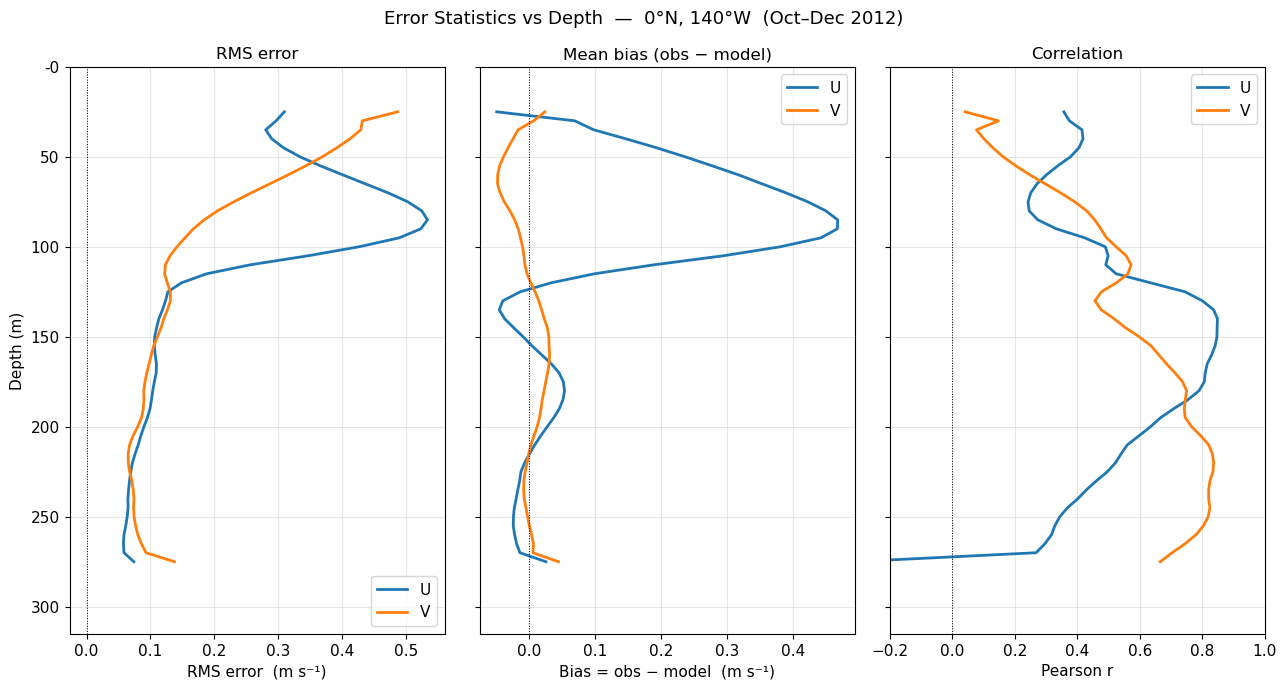

Saved fig5_error_profiles.png


In [42]:
rms_U  = np.sqrt(np.nanmean(dU_day**2, axis=0))
rms_V  = np.sqrt(np.nanmean(dV_day**2, axis=0))
bias_U = np.nanmean(dU_day, axis=0)
bias_V = np.nanmean(dV_day, axis=0)

# Correlation profile
corr_U = np.full(n_z, np.nan)
corr_V = np.full(n_z, np.nan)
for k in range(n_z):
    u_o = U_day[:, k];  u_m = Ue_day[:, k]
    v_o = V_day[:, k];  v_m = Ve_day[:, k]
    mask_u = ~np.isnan(u_o) & ~np.isnan(u_m)
    mask_v = ~np.isnan(v_o) & ~np.isnan(v_m)
    if mask_u.sum() > 5:
        corr_U[k] = np.corrcoef(u_o[mask_u], u_m[mask_u])[0, 1]
    if mask_v.sum() > 5:
        corr_V[k] = np.corrcoef(v_o[mask_v], v_m[mask_v])[0, 1]

fig, axes = plt.subplots(1, 3, figsize=(13, 7), sharey=True)
fig.suptitle('Error Statistics vs Depth  —  0°N, 140°W  (Oct–Dec 2012)', fontsize=13)

# RMS
axes[0].plot(rms_U, Z, color='C0', lw=2, label='U')
axes[0].plot(rms_V, Z, color='C1', lw=2, label='V')
axes[0].set_xlabel('RMS error  (m s⁻¹)')
axes[0].set_ylabel('Depth (m)')
axes[0].set_title('RMS error')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].axvline(0, color='k', lw=0.7, ls=':')

# Bias
axes[1].plot(bias_U, Z, color='C0', lw=2, label='U')
axes[1].plot(bias_V, Z, color='C1', lw=2, label='V')
axes[1].axvline(0, color='k', lw=0.7, ls=':')
axes[1].set_xlabel('Bias = obs − model  (m s⁻¹)')
axes[1].set_title('Mean bias (obs − model)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Correlation
axes[2].plot(corr_U, Z, color='C0', lw=2, label='U')
axes[2].plot(corr_V, Z, color='C1', lw=2, label='V')
axes[2].axvline(0, color='k', lw=0.7, ls=':')
axes[2].set_xlabel('Pearson r')
axes[2].set_title('Correlation')
axes[2].set_xlim([-0.2, 1.0])
axes[2].legend()
axes[2].grid(alpha=0.3)

for ax in axes:
    ax.set_ylim([-315, 0])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{-y:.0f}'))

fig.tight_layout()
plt.savefig('fig5_error_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig5_error_profiles.png')

## 7. Time series at selected depths

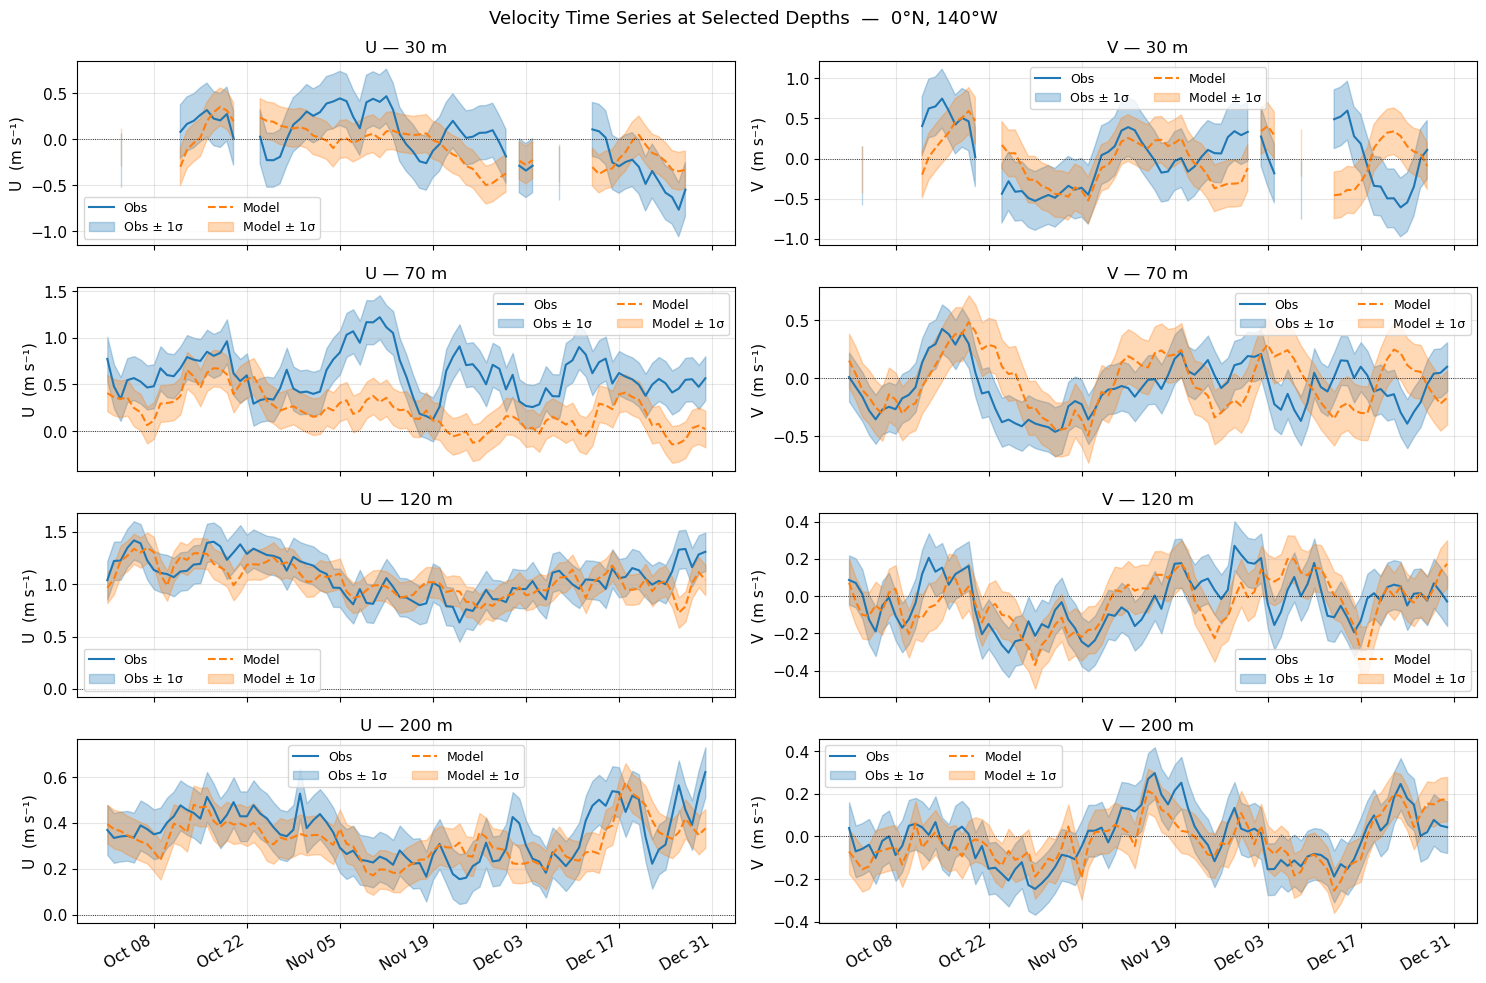

Saved fig6_timeseries.png


In [48]:
# Pick representative depth levels
target_depths = [30, 70, 120, 200]   # metres below surface
depth_labels  = ['30 m', '70 m', '120 m', '200 m']
depth_idx     = [np.argmin(np.abs(depths - d)) for d in target_depths]

fig, axes = plt.subplots(len(target_depths), 2, figsize=(15, 10), sharex=True)
fig.suptitle('Velocity Time Series at Selected Depths  —  0°N, 140°W', fontsize=13)

for row, (di, dlabel) in enumerate(zip(depth_idx, depth_labels)):
    actual_depth = depths[di]

    # U and std dev
    ax = axes[row, 0]
    ax.plot(T, U_day[:, di],  color='C0', lw=1.5, label='Obs')
    ax.fill_between(T, U_day[:, di] - np.nanstd(U_day[:, di]), U_day[:, di] + np.nanstd(U_day[:, di]), color='C0', alpha=0.3, label='Obs ± 1σ')
    ax.plot(T, Ue_day[:, di], color='C1', lw=1.5, ls='--', label='Model')
    ax.fill_between(T, Ue_day[:, di] - np.nanstd(Ue_day[:, di]), Ue_day[:, di] + np.nanstd(Ue_day[:, di]), color='C1', alpha=0.3, label='Model ± 1σ')
    ax.axhline(0, color='k', lw=0.6, ls=':')
    ax.set_ylabel('U  (m s⁻¹)')
    ax.set_title(f'U — {dlabel}')
    ax.legend(fontsize=9, ncol=2)
    ax.grid(alpha=0.3)
    # ax.set_ylim([-1.0, 1.5])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))

    # V
    ax = axes[row, 1]
    ax.plot(T, V_day[:, di],  color='C0', lw=1.5, label='Obs')
    ax.fill_between(T, V_day[:, di] - np.nanstd(V_day[:, di]), V_day[:, di] + np.nanstd(V_day[:, di]), color='C0', alpha=0.3, label='Obs ± 1σ')
    ax.plot(T, Ve_day[:, di], color='C1', lw=1.5, ls='--', label='Model')
    ax.fill_between(T, Ve_day[:, di] - np.nanstd(Ve_day[:, di]), Ve_day[:, di] + np.nanstd(Ve_day[:, di]), color='C1', alpha=0.3, label='Model ± 1σ')
    ax.axhline(0, color='k', lw=0.6, ls=':')
    ax.set_ylabel('V  (m s⁻¹)')
    ax.set_title(f'V — {dlabel}')
    ax.legend(fontsize=9, ncol=2)
    ax.grid(alpha=0.3)
    # ax.set_ylim([-1.0, 1.0])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))

for ax in axes[-1]:
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.tight_layout()
plt.savefig('fig6_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig6_timeseries.png')

## 8. Scatter plots: obs vs model

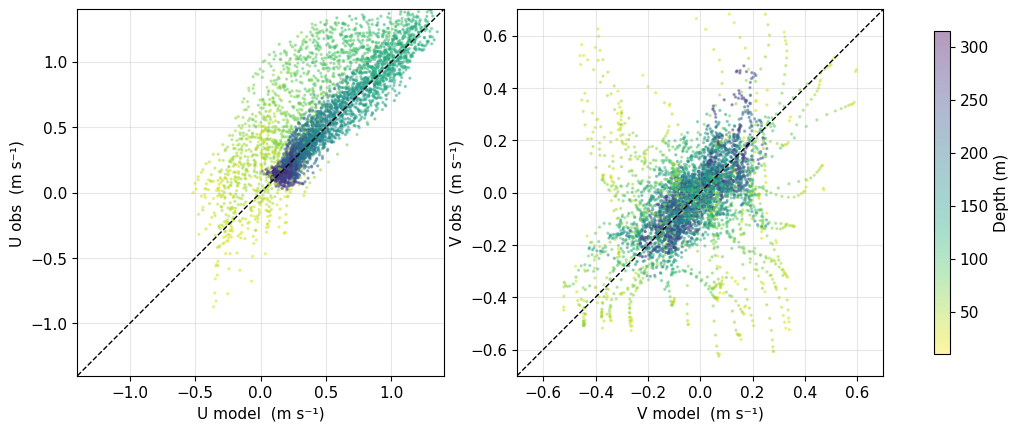

Saved fig7_scatter.png


In [57]:
# Flatten daily arrays and color by depth
depth_tile = np.tile(depths, (n_days, 1))   # (n_days, n_z)

def scatter_vs_model(ax, obs, model, depth, comp, vrange):
    mask = ~np.isnan(obs) & ~np.isnan(model)
    o, m, d = obs[mask], model[mask], depth[mask]
    sc = ax.scatter(m, o, c=d, cmap='viridis_r', s=2, alpha=0.4,
                    vmin=depths.min(), vmax=depths.max(), rasterized=True)
    lims = [vrange[0], vrange[1]]
    ax.plot(lims, lims, 'k--', lw=1, label='1:1')
    r   = np.corrcoef(o, m)[0, 1]
    rms = np.sqrt(np.mean((o - m)**2))
    bias = np.mean(o - m)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f'{comp} model  (m s⁻¹)')
    ax.set_ylabel(f'{comp} obs  (m s⁻¹)')
    # ax.set_title(f'{comp}:  r = {r:.3f}  |  RMS = {rms:.3f} m s⁻¹  |  bias = {bias:+.3f} m s⁻¹')
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    return sc

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
# fig.suptitle('Obs vs Model Scatter  —  0°N, 140°W  (Oct–Dec 2012, daily means)', fontsize=13)

sc_u = scatter_vs_model(axes[0], U_day.ravel(),  Ue_day.ravel(), depth_tile.ravel(), 'U', [-1.4, 1.4])
sc_v = scatter_vs_model(axes[1], V_day.ravel(),  Ve_day.ravel(), depth_tile.ravel(), 'V', [-0.7, 0.7])

cb = fig.colorbar(sc_u, ax=axes.ravel(), shrink=0.7, pad=0.05)
cb.set_label('Depth (m)')

# fig.tight_layout()
plt.savefig('TAO_comparison/fig7_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig7_scatter.png')

## 9. Summary statistics

In [ ]:
def compute_stats(obs, model):
    mask = ~np.isnan(obs) & ~np.isnan(model)
    o, m = obs[mask], model[mask]
    diff = o - m
    r    = np.corrcoef(o, m)[0, 1]
    rms  = np.sqrt(np.mean(diff**2))
    bias = np.mean(diff)
    std_o = np.std(o)
    std_m = np.std(m)
    nss   = 1 - np.mean(diff**2) / np.var(o)   # Nash-Sutcliffe
    n     = mask.sum()
    return dict(r=r, rms=rms, bias=bias, std_obs=std_o, std_model=std_m, nss=nss, n=n)

# Depth-band masks
bands = [
    ('All depths',       (depths >= 10)  & (depths <= 315)),
    ('Upper 100 m',      (depths >= 10)  & (depths <= 100)),
    ('100–200 m',        (depths > 100)  & (depths <= 200)),
    ('200–315 m',        (depths > 200)  & (depths <= 315)),
]

rows = []
for band_name, band_mask in bands:
    for comp, obs_arr, mod_arr in [('U', U_day, Ue_day), ('V', V_day, Ve_day)]:
        s = compute_stats(obs_arr[:, band_mask].ravel(), mod_arr[:, band_mask].ravel())
        rows.append({'Depth band': band_name, 'Component': comp, **s})

df = pd.DataFrame(rows).set_index(['Depth band', 'Component'])
df = df.rename(columns={'r': 'Corr (r)', 'rms': 'RMS (m/s)', 'bias': 'Bias (m/s)',
                          'std_obs': 'σ_obs', 'std_model': 'σ_model', 'nss': 'NSS', 'n': 'N'})
df = df.round({'Corr (r)': 3, 'RMS (m/s)': 4, 'Bias (m/s)': 4,
               'σ_obs': 4, 'σ_model': 4, 'NSS': 3})

print('=== Summary Statistics: TPOSE24 vs TAO ADCP  (0°N, 140°W, Oct–Dec 2012) ===')
print(df.to_string())

In [ ]:
# Render as a figure for export
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

df_reset = df.reset_index()
col_labels = list(df_reset.columns)
table_data = df_reset.values.tolist()

tbl = ax.table(cellText=table_data, colLabels=col_labels,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.6)

# Shade header
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#4472C4')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Shade alternating rows
for i in range(1, len(table_data) + 1):
    for j in range(len(col_labels)):
        if i % 2 == 0:
            tbl[i, j].set_facecolor('#D9E1F2')

ax.set_title('TPOSE24 vs TAO ADCP  —  0°N, 140°W  (Oct–Dec 2012)',
             fontsize=12, pad=15)

fig.tight_layout()
plt.savefig('TAO_comparison/fig8_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig8_summary_table.png')